# Fermeture $w_{sec}\partial_z\bar u$ / bulk-plume (Romps 2014), UCLA-CRM RCE `large300`

## §0. Setup commun

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import xarray as xr
import gc, os
from scipy.ndimage import uniform_filter1d

plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.grid':True,
                     'grid.alpha':0.25,'image.cmap':'RdBu_r'})
Rd,Rv=287.05,461.5; EPSILON=Rd/Rv; g=9.81; cp=1004.0; p_ref=1e5
Z_TOP_KM=15.0

DIR = os.path.join(os.path.expanduser('~'), 'Desktop', 'SCALE')
def path3d(v): return os.path.join(f'SCALE_RCE_large300_3D_{v}.nc')
BLOC = 10   # taille de bloc temporel — augmente si tu as beaucoup de RAM, baisse si erreur memoire

_ds=xr.open_dataset(path3d('ua')); _da=_ds['ua']
dim_t,dim_z,dim_y,dim_x=_da.dims[:4]
n_t,n_z=_da.sizes[dim_t],_da.sizes[dim_z]; n_y,n_x=_da.sizes[dim_y],_da.sizes[dim_x]
alt=_ds[dim_z].values.astype(float).copy()
_ds.close(); del _ds,_da; gc.collect()
zkm=alt/1000.0
mask_show=alt<=Z_TOP_KM*1000; m28=(alt>=2000)&(alt<=8000); m812=(alt>=8000)&(alt<=12000)
m015=(alt>=0)&(alt<=2000); m212=(alt>=2000)&(alt<=12000); m112=(alt>=1000)&(alt<=12000)

t_stat=0; idx_stat=slice(t_stat,None); n_stat=n_t-t_stat
dt_phys=6*3600.0   # A VERIFIER : pas de temps entre snapshots 3D SCALE
tt=np.arange(n_stat)

def smooth_t(fld, win=8):
    return uniform_filter1d(fld, size=win, axis=1, mode='nearest')

def load_ordered(da, *dims_voulues):
    """Lit un DataArray dans son ordre natif (rapide), reordonne EN MEMOIRE ensuite."""
    ordre_natif = da.dims
    raw = da.values
    perm = [ordre_natif.index(d) for d in dims_voulues]
    return np.transpose(raw, perm)

print(f'dims : t={dim_t}, z={dim_z}, y={dim_y}, x={dim_x}')
print(f'altitude : min={alt.min():.1f} max={alt.max():.1f} (doit etre en metres, croissant, ~0-30000)')
print(f'{n_t}t x {n_z}z x {n_y}y x {n_x}x')


dims : t=time, z=lev, y=y, x=x
altitude : min=37.0 max=33000.0 (doit etre en metres, croissant, ~0-30000)
100t x 74z x 128y x 2048x


## §0bis. PRW reconstruit (aucune variable native) et masques humide/sec

In [2]:
# ============================================================
#  PRW = (1/g) * integrale(hus dp), par bloc de temps
# ============================================================
prw_sum = np.zeros((n_y, n_x))
ds_hus = xr.open_dataset(path3d('hus')); ds_pa = xr.open_dataset(path3d('pa'))
for t0 in range(t_stat, n_t, BLOC):
    t1 = min(t0+BLOC, n_t); sl = {dim_t: slice(t0,t1)}
    qv = load_ordered(ds_hus['hus'].isel(sl), dim_t, dim_z, dim_y, dim_x)
    p  = load_ordered(ds_pa['pa'].isel(sl),   dim_t, dim_z, dim_y, dim_x)
    pwv_block = np.trapz(qv, p, axis=1)
    prw_sum += -pwv_block.sum(axis=0)/g
    del qv, p, pwv_block; gc.collect()
ds_hus.close(); ds_pa.close(); gc.collect()
prw_mean_arr = prw_sum / n_stat

PRW_SEUIL = float(np.median(prw_mean_arr.ravel()))
mh = (prw_mean_arr > PRW_SEUIL); ms = ~mh; mh_flat = mh.ravel(); ms_flat = ms.ravel()
f_h = float(mh.mean()); f_s = float(ms.mean())

print(f'PRW reconstruit : moyenne={prw_mean_arr.mean():.2f} kg/m2 (attendu ~20-60 en tropical)')
print(f'humide={f_h:.0%} sec={f_s:.0%}')


PRW reconstruit : moyenne=32.28 kg/m2 (attendu ~20-60 en tropical)
humide=50% sec=50%


## §1. Champs de base, rho0, theta, T, ubar, wbar, flux de Reynolds, decomposition humide/sec

In [3]:
# ============================================================
#  rho0(z), theta(z,t), T(z,t) — par bloc de temps, tous niveaux d'un coup
# ============================================================
rho0_sum=np.zeros(n_z); n_rho=0
theta_zt=np.zeros((n_z,n_stat)); T_zt=np.zeros((n_z,n_stat))
ds_ta=xr.open_dataset(path3d('ta')); ds_pa=xr.open_dataset(path3d('pa')); ds_hus=xr.open_dataset(path3d('hus'))
for t0 in range(t_stat,n_t,BLOC):
    t1=min(t0+BLOC,n_t); sl={dim_t:slice(t0,t1)}
    T = load_ordered(ds_ta['ta'].isel(sl),  dim_t, dim_z, dim_y, dim_x)
    p = load_ordered(ds_pa['pa'].isel(sl),  dim_t, dim_z, dim_y, dim_x)
    qv = load_ordered(ds_hus['hus'].isel(sl), dim_t, dim_z, dim_y, dim_x)
    Tv=T*(1+qv/EPSILON)/(1+qv); rho=p/(Rd*Tv)
    rho0_sum+=rho.mean(axis=(0,2,3))*(t1-t0); n_rho+=(t1-t0)
    theta = T*(p_ref/p)**(Rd/cp)
    theta_zt[:, t0:t1] = theta.mean(axis=(2,3)).T
    T_zt[:, t0:t1]     = T.mean(axis=(2,3)).T
    del T,p,qv,Tv,rho,theta; gc.collect()
ds_ta.close(); ds_pa.close(); ds_hus.close()
rho0=rho0_sum/n_rho
dthetadz_zt=np.gradient(theta_zt, alt, axis=0)
print('rho0, theta_zt, T_zt, dthetadz_zt : ok')


rho0, theta_zt, T_zt, dthetadz_zt : ok


In [4]:
# ============================================================
#  ubar_zt, wbar_zt, flux_zt (u'w') + u_h/s_zt, w_h/s_zt (humide/sec) — par bloc de temps
# ============================================================
ubar_zt=np.zeros((n_z,n_stat)); wbar_zt=np.zeros((n_z,n_stat)); flux_zt=np.zeros((n_z,n_stat))
u_h_zt=np.zeros((n_z,n_stat)); u_s_zt=np.zeros((n_z,n_stat))
w_h_zt=np.zeros((n_z,n_stat)); w_s_zt=np.zeros((n_z,n_stat))
ds_u=xr.open_dataset(path3d('ua')); ds_w=xr.open_dataset(path3d('wa'))
for t0 in range(t_stat,n_t,BLOC):
    t1=min(t0+BLOC,n_t); sl={dim_t:slice(t0,t1)}
    u = load_ordered(ds_u['ua'].isel(sl), dim_t, dim_z, dim_y, dim_x).reshape(t1-t0, n_z, -1)
    w = load_ordered(ds_w['wa'].isel(sl), dim_t, dim_z, dim_y, dim_x).reshape(t1-t0, n_z, -1)
    ub = u.mean(axis=2); wb = w.mean(axis=2)
    up = u - ub[:,:,None]; wp = w - wb[:,:,None]
    ubar_zt[:,t0:t1] = ub.T; wbar_zt[:,t0:t1] = wb.T
    flux_zt[:,t0:t1] = (rho0[None,:]*(up*wp).mean(axis=2)).T
    u_h_zt[:,t0:t1] = u[:,:,mh_flat].mean(axis=2).T
    u_s_zt[:,t0:t1] = u[:,:,ms_flat].mean(axis=2).T
    w_h_zt[:,t0:t1] = w[:,:,mh_flat].mean(axis=2).T
    w_s_zt[:,t0:t1] = w[:,:,ms_flat].mean(axis=2).T
    del u,w,ub,wb,up,wp; gc.collect()
ds_u.close(); ds_w.close(); gc.collect()

dudz_tot=np.gradient(ubar_zt, alt, axis=0)
uw_zt=flux_zt/rho0[:,None]
terme_flux=smooth_t(-(1/rho0[:,None])*np.gradient(flux_zt, alt, axis=0))
dudz_tot_s=smooth_t(dudz_tot); w_s_obs_s=smooth_t(w_s_zt)
print('ubar_zt, wbar_zt, flux_zt, u_h/s_zt, w_h/s_zt, terme_flux : ok')


ubar_zt, wbar_zt, flux_zt, u_h/s_zt, w_h/s_zt, terme_flux : ok


In [5]:
# ============================================================
#  tntr(z,t) — par bloc de temps
# ============================================================
tntr_zt=np.zeros((n_z,n_stat))
ds_tntr=xr.open_dataset(path3d('tntr'))
for t0 in range(t_stat,n_t,BLOC):
    t1=min(t0+BLOC,n_t); sl={dim_t:slice(t0,t1)}
    tr = load_ordered(ds_tntr['tntr'].isel(sl), dim_t, dim_z, dim_y, dim_x)
    tntr_zt[:,t0:t1] = tr.mean(axis=(2,3)).T
    del tr; gc.collect()
ds_tntr.close(); gc.collect()

with np.errstate(divide='ignore', invalid='ignore'):
    w_sec_rce_brut     = -tntr_zt/dthetadz_zt
    w_sec_rce_corrige  = -(theta_zt/T_zt)*tntr_zt/dthetadz_zt
w_sec_rce_brut_s    = smooth_t(w_sec_rce_brut)
w_sec_rce_corrige_s = smooth_t(w_sec_rce_corrige)
w_sec_rce_x_shear    = smooth_t(w_sec_rce_corrige*dudz_tot)
print('tntr_zt, w_sec_rce, fermeture radiative : ok')


tntr_zt, w_sec_rce, fermeture radiative : ok


## §2. Affichage final, fermeture radiative-subsidente sur 2–8 km

/tmp/ipykernel_36689/385031381.py:5: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(tt+t_stat, zkm[m28], fld[m28], cmap='RdBu_r',


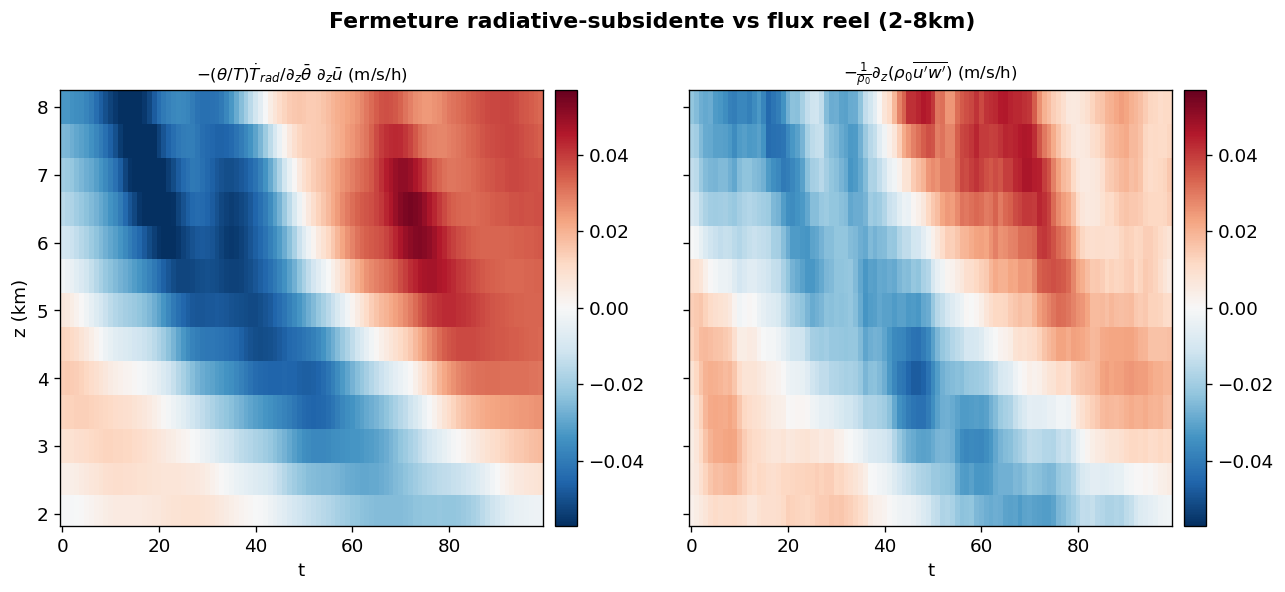

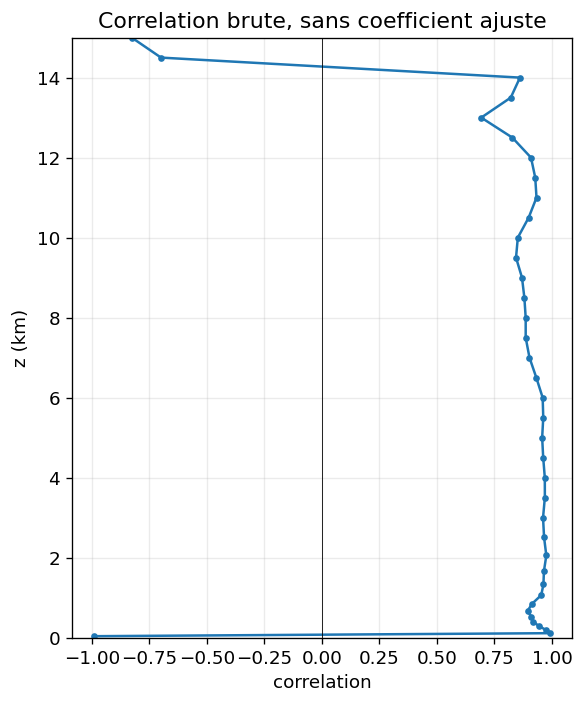

In [6]:
fig, axes = plt.subplots(1,2,figsize=(11,5),sharey=True)
v = max(np.percentile(np.abs(terme_flux[m28]),98), np.percentile(np.abs(w_sec_rce_x_shear[m28]),98))*3600+1e-12
for ax,(fld,lab) in zip(axes,[(w_sec_rce_x_shear*3600, r"$-(\theta/T)\dot T_{rad}/\partial_z\bar\theta\ \partial_z\bar u$ (m/s/h)"),
                                (terme_flux*3600, r"$-\frac{1}{\rho_0}\partial_z(\rho_0\overline{u'w'})$ (m/s/h)")]):
    im=ax.pcolormesh(tt+t_stat, zkm[m28], fld[m28], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0,-v,v), shading='auto')
    ax.set_xlabel('t'); ax.set_title(lab,fontsize=10)
    fig.colorbar(im,ax=ax,pad=.02)
axes[0].set_ylabel('z (km)')
plt.suptitle('Fermeture radiative-subsidente vs flux reel (2-8km)', fontweight='bold')
plt.tight_layout(); plt.show()

r_brut = np.full(n_z, np.nan)
for iz in range(n_z):
    x, y = w_sec_rce_x_shear[iz,:], terme_flux[iz,:]
    if np.nanstd(x) < 1e-15 or np.nanstd(y) < 1e-15: continue
    r_brut[iz] = np.corrcoef(x,y)[0,1]
fig, ax = plt.subplots(figsize=(5,6))
ax.plot(r_brut[mask_show], zkm[mask_show], 'o-', ms=3); ax.axvline(0,color='k',lw=.5)
ax.set_xlabel('correlation'); ax.set_ylabel('z (km)'); ax.set_ylim(0,Z_TOP_KM)
ax.set_title('Correlation brute, sans coefficient ajuste')
plt.tight_layout(); plt.show()


## §3. Bulk-plume a la Romps (2014), M, u_c, epsilon, D, jusqu'a 12km

fraction de points (z,t) valides sur 2-12km avec N_MIN_POINTS=200 : 71%


/tmp/ipykernel_36689/1589391703.py:66: RuntimeWarning: All-NaN slice encountered
  D_z_composite = np.nanmedian(D_zt, axis=1)


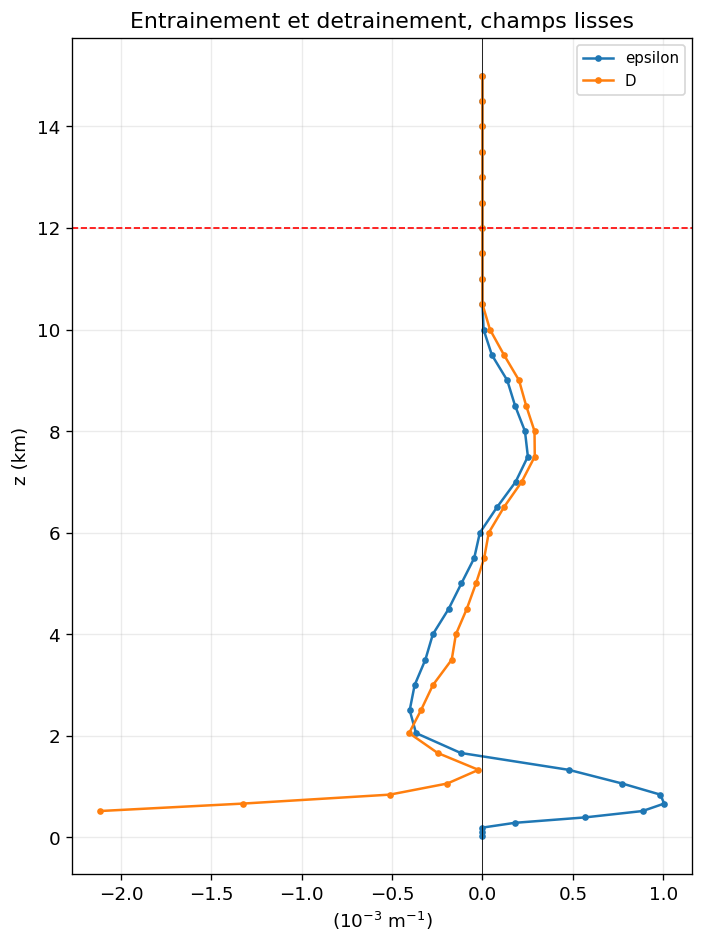

/tmp/ipykernel_36689/1589391703.py:85: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(tt+t_stat, zkm[m212], fld[m212], cmap='RdBu_r',


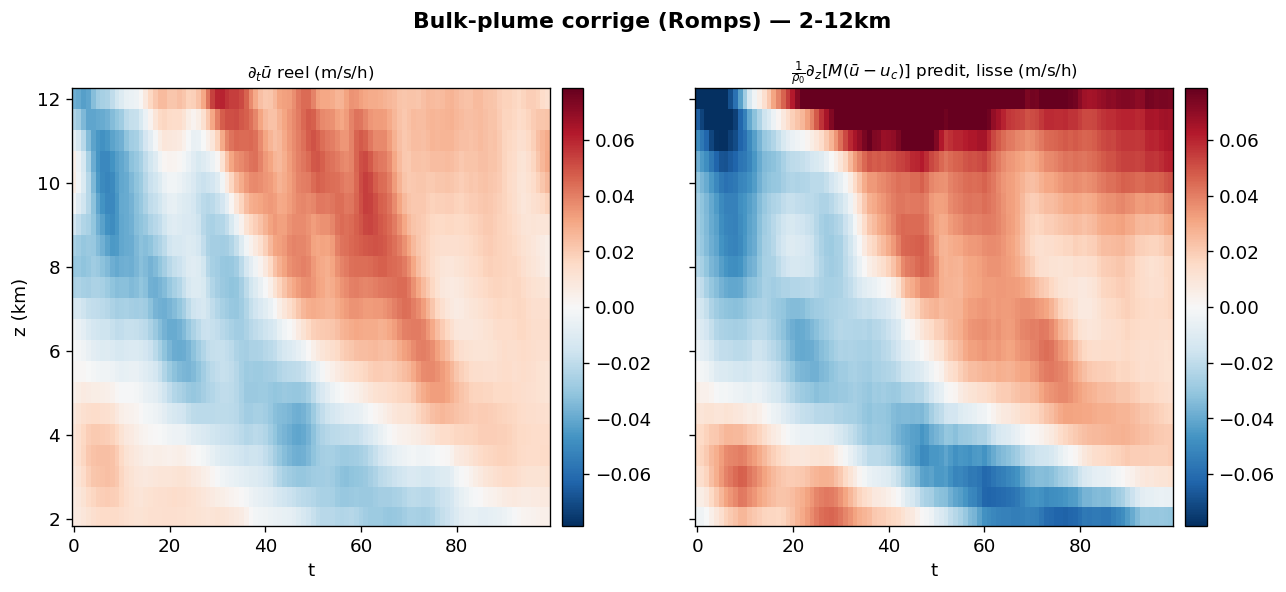

In [7]:
# AAAAAAAAAAAAAAAAAAAAAA============================================================
#  Bulk-plume a la Romps (2014), corrige pour bien modeliser jusqu'a 12km
#  1) M(z,t), u_c(z,t) avec seuil d'echantillon renforce
#  2) lissage vertical (comblement + moyenne glissante), comme le fit
#     quadratique que Romps applique a epsilon avant de l'utiliser
#  3) epsilon(z,t), D(z,t) sur les champs lisses
#  4) test direct de l'equation testable (eq.2/15) jusqu'a 12km
# ============================================================
from scipy.ndimage import uniform_filter1d

SEUIL_W = 0.5; SEUIL_COND = 1e-5
N_MIN_POINTS = 200
m212 = (alt>=2000)&(alt<=12000)

# ---- 1) M et u_c, masque nuage + seuil d'echantillon ----
M_zt = np.full((n_z, n_stat), np.nan)
uc_zt = np.full((n_z, n_stat), np.nan)
f_cloud_zt = np.zeros((n_z, n_stat))

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
ds_clw = xr.open_dataset(path3d('clw'))
for iz in range(n_z):
    u = ds_u['ua'].isel({dim_t:idx_stat,dim_z:iz}).values.reshape(n_stat,-1)
    w = ds_w['wa'].isel({dim_t:idx_stat,dim_z:iz}).values.reshape(n_stat,-1)
    clw = ds_clw['clw'].isel({dim_t:idx_stat,dim_z:iz}).values.reshape(n_stat,-1)
    cloud = (w > SEUIL_W) & ((clw) > SEUIL_COND)
    for it in range(n_stat):
        m = cloud[it,:]; f_cloud_zt[iz,it] = m.mean()
        if m.sum() >= N_MIN_POINTS:
            w_m = w[it,m]; u_m = u[it,m]
            M_zt[iz,it] = rho0[iz] * f_cloud_zt[iz,it] * w_m.mean()
            uc_zt[iz,it] = np.sum(w_m*u_m)/np.sum(w_m)
    del u,w,clw,cloud
ds_u.close(); ds_w.close(); ds_clw.close(); gc.collect()

frac_valide = np.mean(np.isfinite(uc_zt[m212]))
print(f"fraction de points (z,t) valides sur 2-12km avec N_MIN_POINTS={N_MIN_POINTS} : {frac_valide:.0%}")

# ---- 2) comblement + lissage vertical de M et u_c ----
def combler_et_lisser(champ_zt, fallback_zt, win=5):
    out = champ_zt.copy()
    for it in range(n_stat):
        col = out[:,it]
        valid = np.isfinite(col)
        if valid.sum() < 3:
            out[:,it] = fallback_zt[:,it]; continue
        out[:,it] = np.interp(alt, alt[valid], col[valid])
    return uniform_filter1d(out, size=win, axis=0, mode='nearest')

M_zt_lisse  = combler_et_lisser(M_zt,  np.zeros_like(M_zt))
uc_zt_lisse = combler_et_lisser(uc_zt, ubar_zt)

# ---- 3) epsilon(z,t) et D(z,t) sur champs lisses ----
duc_dz_zt = np.gradient(uc_zt_lisse, alt, axis=0)
denom_zt = ubar_zt - uc_zt_lisse
echelle = np.nanpercentile(np.abs(denom_zt[m212]), 90)
with np.errstate(divide='ignore', invalid='ignore'):
    eps_zt = np.where(np.abs(denom_zt) > 0.3*echelle, duc_dz_zt/denom_zt, np.nan)

dMdz_zt = np.gradient(M_zt_lisse, alt, axis=0)
echelle_M = np.nanpercentile(np.abs(M_zt_lisse[m212]), 90)
with np.errstate(divide='ignore', invalid='ignore'):
    D_zt = np.where(np.abs(M_zt_lisse) > 0.3*echelle_M, eps_zt - dMdz_zt/M_zt_lisse, np.nan)

eps_z_composite = np.nanmedian(eps_zt, axis=1)
D_z_composite = np.nanmedian(D_zt, axis=1)

fig, ax = plt.subplots(figsize=(6,8))
ax.plot(eps_z_composite[mask_show]*1e3, zkm[mask_show], 'o-', ms=3, label='epsilon')
ax.plot(D_z_composite[mask_show]*1e3, zkm[mask_show], 'o-', ms=3, label='D')
ax.axhline(12, color='r', lw=1, ls='--'); ax.axvline(0,color='k',lw=.5); ax.legend(fontsize=9)
ax.set_xlabel(r'($10^{-3}$ m$^{-1}$)'); ax.set_ylabel('z (km)')
ax.set_title("Entrainement et detrainement, champs lisses")
plt.tight_layout(); plt.show()

# ---- 4) test direct de l'equation testable, jusqu'a 12km ----
dudt_pred = (1/rho0[:,None]) * np.gradient(M_zt_lisse*(ubar_zt - uc_zt_lisse), alt, axis=0)
dudt_pred_s = smooth_t(dudt_pred)
dudt_reel = smooth_t(np.gradient(ubar_zt, dt_phys, axis=1))

fig, axes = plt.subplots(1,2,figsize=(11,5),sharey=True)
v = max(np.nanpercentile(np.abs(dudt_reel[m212]),95), np.nanpercentile(np.abs(dudt_pred_s[m212]),95))*3600+1e-12
for ax,(fld,lab) in zip(axes,[(dudt_reel*3600, r"$\partial_t\bar u$ reel (m/s/h)"),
                                (dudt_pred_s*3600, r"$\frac{1}{\rho_0}\partial_z[M(\bar u-u_c)]$ predit, lisse (m/s/h)")]):
    im=ax.pcolormesh(tt+t_stat, zkm[m212], fld[m212], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0,-v,v), shading='auto')
    ax.set_xlabel('t'); ax.set_title(lab,fontsize=10)
    fig.colorbar(im,ax=ax,pad=.02)
axes[0].set_ylabel('z (km)')
plt.suptitle("Bulk-plume corrige (Romps) — 2-12km", fontweight='bold')
plt.tight_layout(); plt.show()


/tmp/ipykernel_36689/588796197.py:28: RuntimeWarning: All-NaN slice encountered
  D_z_composite = np.nanmedian(D_zt, axis=1)


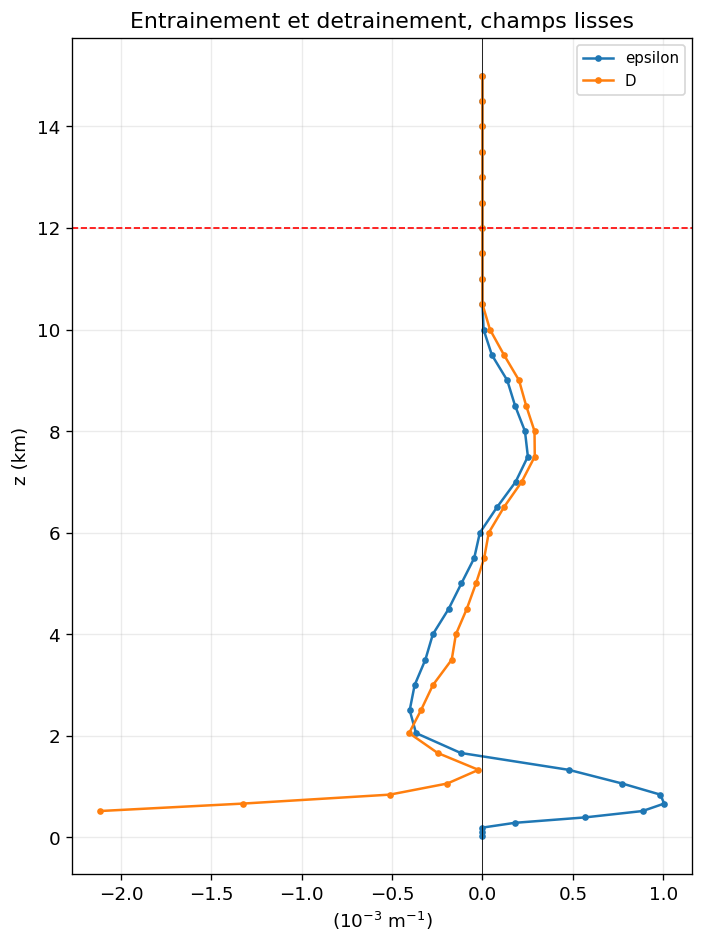

In [8]:
# ============================================================
#  comblement + lissage vertical de M et u_c
# ============================================================
def combler_et_lisser(champ_zt, fallback_zt, win=5):
    out = champ_zt.copy()
    for it in range(n_stat):
        col = out[:,it]; valid = np.isfinite(col)
        if valid.sum() < 3:
            out[:,it] = fallback_zt[:,it]; continue
        out[:,it] = np.interp(alt, alt[valid], col[valid])
    return uniform_filter1d(out, size=win, axis=0, mode='nearest')

M_zt_lisse  = combler_et_lisser(M_zt,  np.zeros_like(M_zt))
uc_zt_lisse = combler_et_lisser(uc_zt, ubar_zt)

duc_dz_zt = np.gradient(uc_zt_lisse, alt, axis=0)
denom_zt = ubar_zt - uc_zt_lisse
echelle = np.nanpercentile(np.abs(denom_zt[m212]), 90)
with np.errstate(divide='ignore', invalid='ignore'):
    eps_zt = np.where(np.abs(denom_zt) > 0.3*echelle, duc_dz_zt/denom_zt, np.nan)

dMdz_zt = np.gradient(M_zt_lisse, alt, axis=0)
echelle_M = np.nanpercentile(np.abs(M_zt_lisse[m212]), 90)
with np.errstate(divide='ignore', invalid='ignore'):
    D_zt = np.where(np.abs(M_zt_lisse) > 0.3*echelle_M, eps_zt - dMdz_zt/M_zt_lisse, np.nan)

eps_z_composite = np.nanmedian(eps_zt, axis=1)
D_z_composite = np.nanmedian(D_zt, axis=1)

fig, ax = plt.subplots(figsize=(6,8))
ax.plot(eps_z_composite[mask_show]*1e3, zkm[mask_show], 'o-', ms=3, label='epsilon')
ax.plot(D_z_composite[mask_show]*1e3, zkm[mask_show], 'o-', ms=3, label='D')
ax.axhline(12, color='r', lw=1, ls='--'); ax.axvline(0,color='k',lw=.5); ax.legend(fontsize=9)
ax.set_xlabel(r'($10^{-3}$ m$^{-1}$)'); ax.set_ylabel('z (km)')
ax.set_title('Entrainement et detrainement, champs lisses')
plt.tight_layout(); plt.show()


## §4. Test direct de la prediction bulk-plume, jusqu'a 12km

/tmp/ipykernel_36689/2684320502.py:9: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(tt+t_stat, zkm[m212], fld[m212], cmap='RdBu_r',


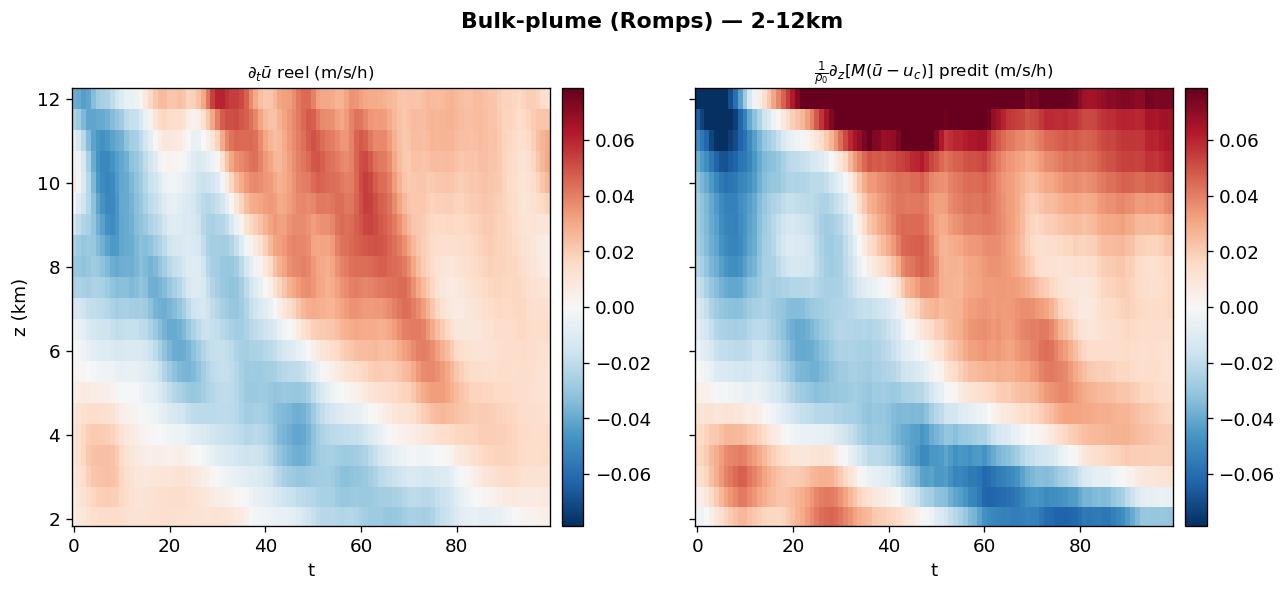

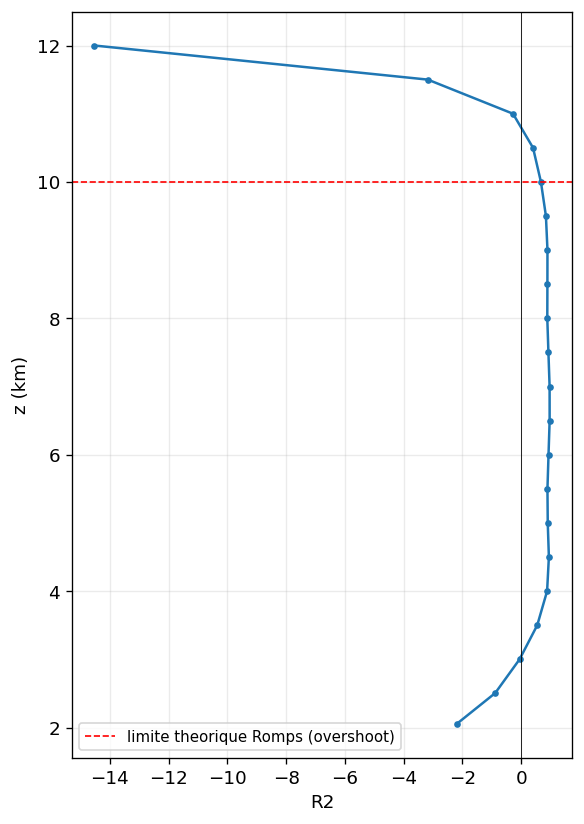

R2 median 2-8km  : 0.89
R2 median 8-12km : 0.67


In [9]:
dudt_pred = (1/rho0[:,None]) * np.gradient(M_zt_lisse*(ubar_zt - uc_zt_lisse), alt, axis=0)
dudt_pred_s = smooth_t(dudt_pred)
dudt_reel = smooth_t(np.gradient(ubar_zt, dt_phys, axis=1))

fig, axes = plt.subplots(1,2,figsize=(11,5),sharey=True)
v = max(np.nanpercentile(np.abs(dudt_reel[m212]),95), np.nanpercentile(np.abs(dudt_pred_s[m212]),95))*3600+1e-12
for ax,(fld,lab) in zip(axes,[(dudt_reel*3600, r"$\partial_t\bar u$ reel (m/s/h)"),
                                (dudt_pred_s*3600, r"$\frac{1}{\rho_0}\partial_z[M(\bar u-u_c)]$ predit (m/s/h)")]):
    im=ax.pcolormesh(tt+t_stat, zkm[m212], fld[m212], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0,-v,v), shading='auto')
    ax.set_xlabel('t'); ax.set_title(lab,fontsize=10)
    fig.colorbar(im,ax=ax,pad=.02)
axes[0].set_ylabel('z (km)')
plt.suptitle('Bulk-plume (Romps) — 2-12km', fontweight='bold')
plt.tight_layout(); plt.show()

R2_romps = np.full(n_z, np.nan)
for iz in range(n_z):
    if not m212[iz]: continue
    a,b = dudt_reel[iz,:], dudt_pred_s[iz,:]
    ok = np.isfinite(a) & np.isfinite(b)
    if ok.sum()<20 or np.std(a[ok])<1e-15: continue
    ss_res=np.sum((a[ok]-b[ok])**2); ss_tot=np.sum((a[ok]-a[ok].mean())**2)
    R2_romps[iz]=1-ss_res/ss_tot if ss_tot>0 else np.nan

fig, ax = plt.subplots(figsize=(5,7))
ax.plot(R2_romps[m212], zkm[m212], 'o-', ms=3); ax.axvline(0,color='k',lw=.5)
ax.axhline(10, color='r', lw=1, ls='--', label='limite theorique Romps (overshoot)')
ax.set_xlabel('R2'); ax.set_ylabel('z (km)'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f'R2 median 2-8km  : {np.nanmedian(R2_romps[m28]):.2f}')
print(f'R2 median 8-12km : {np.nanmedian(R2_romps[m812]):.2f}')


## §5. Comparaison finale, bulk-plume vs fermeture radiative, correlation et R2 recalibre

/tmp/ipykernel_36689/1289639374.py:14: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(tt+t_stat, zkm[m112], fld[m112], cmap='RdBu_r',


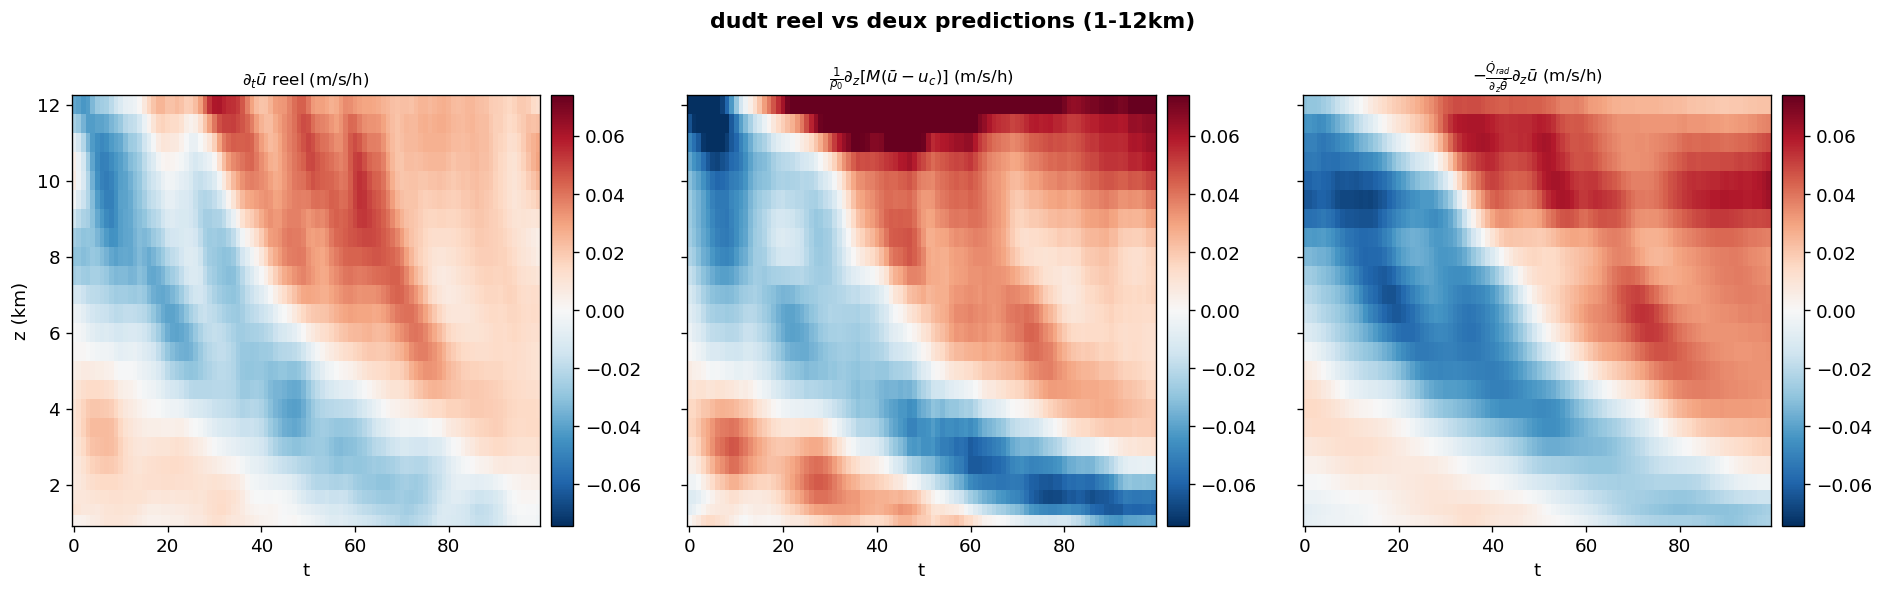

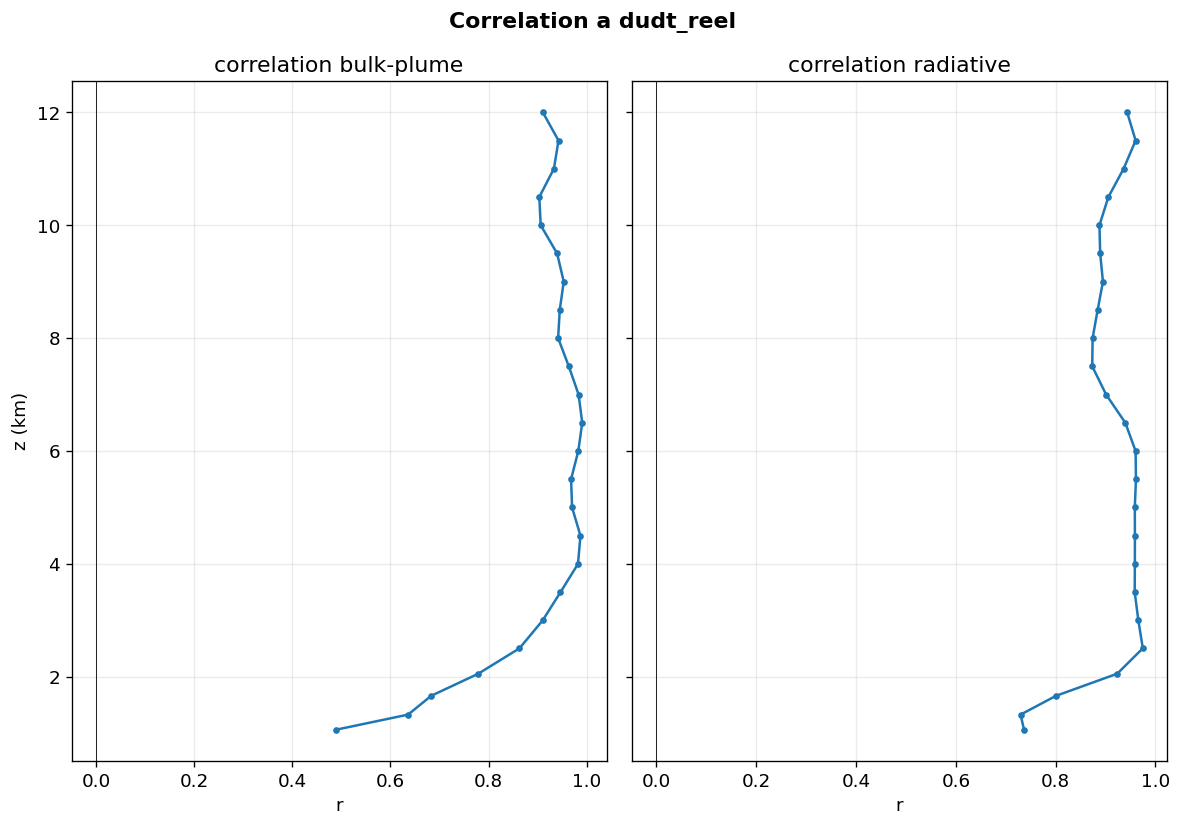

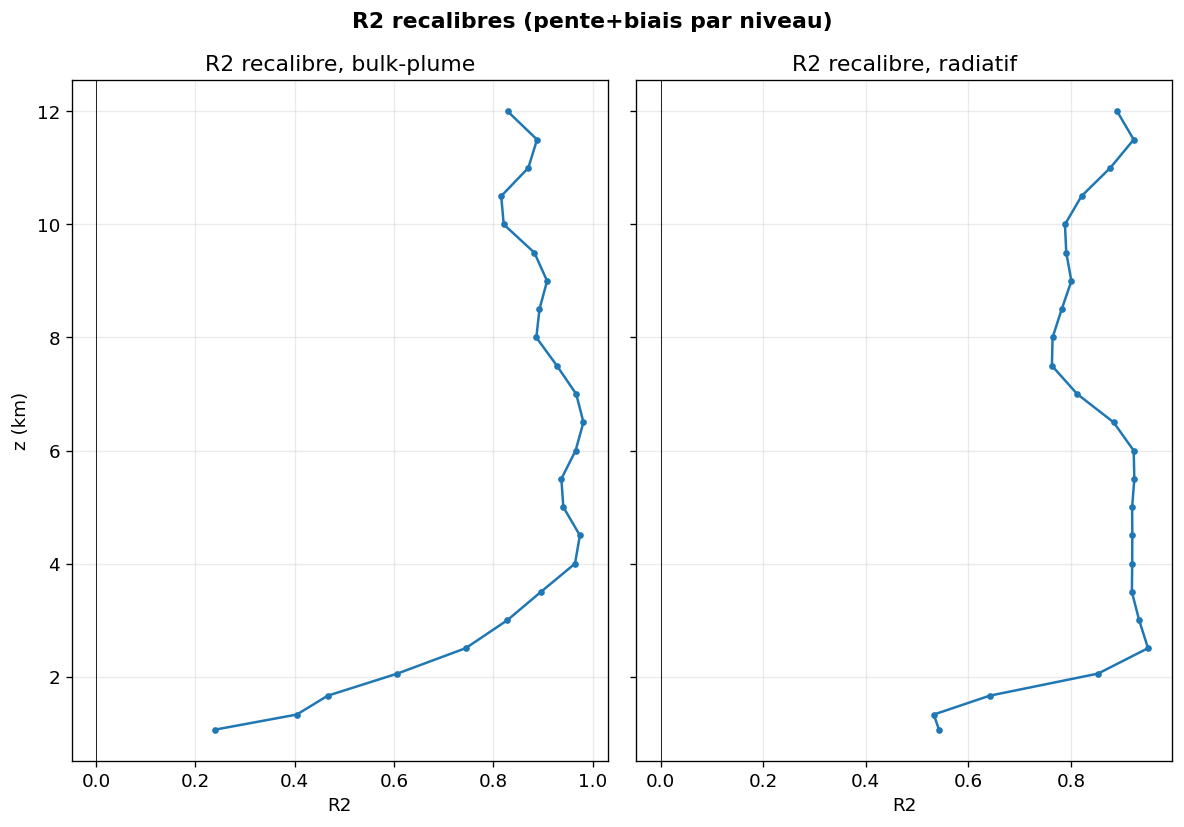

R2 median bulk-plume (2-8km / 8-12km) : 0.94 / 0.88
R2 median radiatif   (2-8km / 8-12km) : 0.92 / 0.80


In [10]:
# ============================================================
#  Trois cartes cote a cote : dudt reel | bulk-plume | radiative
# ============================================================
w_sec_rad = (theta_zt/T_zt) * tntr_zt / dthetadz_zt
dudt_pred_rad = smooth_t(-w_sec_rad * dudz_tot)

fig, axes = plt.subplots(1,3,figsize=(16,5),sharey=True)
v = max(np.nanpercentile(np.abs(dudt_reel[m112]),95),
        np.nanpercentile(np.abs(dudt_pred_s[m112]),95),
        np.nanpercentile(np.abs(dudt_pred_rad[m112]),95))*3600+1e-12
for ax,(fld,lab) in zip(axes,[(dudt_reel*3600, r"$\partial_t\bar u$ reel (m/s/h)"),
                                (dudt_pred_s*3600, r"$\frac{1}{\rho_0}\partial_z[M(\bar u-u_c)]$ (m/s/h)"),
                                (dudt_pred_rad*3600, r"$-\frac{\dot Q_{rad}}{\partial_z\bar\theta}\partial_z\bar u$ (m/s/h)")]):
    im=ax.pcolormesh(tt+t_stat, zkm[m112], fld[m112], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0,-v,v), shading='auto')
    ax.set_xlabel('t'); ax.set_title(lab,fontsize=10)
    fig.colorbar(im,ax=ax,pad=.02)
axes[0].set_ylabel('z (km)')
plt.suptitle('dudt reel vs deux predictions (1-12km)', fontweight='bold')
plt.tight_layout(); plt.show()

# ---- correlation ----
corr_bulk = np.full(n_z, np.nan); corr_rad = np.full(n_z, np.nan)
for iz in range(n_z):
    if not m112[iz]: continue
    a = dudt_reel[iz,:]
    for pred, store in [(dudt_pred_s[iz,:], 'bulk'), (dudt_pred_rad[iz,:], 'rad')]:
        ok = np.isfinite(a) & np.isfinite(pred)
        if ok.sum() < 20 or np.std(a[ok]) < 1e-15 or np.std(pred[ok]) < 1e-15: continue
        r = np.corrcoef(a[ok], pred[ok])[0,1]
        if store == 'bulk': corr_bulk[iz] = r
        else: corr_rad[iz] = r

fig, axes = plt.subplots(1,2,figsize=(10,7),sharey=True)
axes[0].plot(corr_bulk[m112], zkm[m112], 'o-', ms=3); axes[0].axvline(0,color='k',lw=.5)
axes[0].set_title('correlation bulk-plume'); axes[0].set_xlabel('r'); axes[0].set_ylabel('z (km)')
axes[1].plot(corr_rad[m112], zkm[m112], 'o-', ms=3); axes[1].axvline(0,color='k',lw=.5)
axes[1].set_title('correlation radiative'); axes[1].set_xlabel('r')
plt.suptitle('Correlation a dudt_reel', fontweight='bold')
plt.tight_layout(); plt.show()

# ---- R2 recalibre (pente+biais) ----
def r2_recalibre(pred):
    pente = np.full(n_z, np.nan); biais = np.full(n_z, np.nan)
    for iz in range(n_z):
        if not m112[iz]: continue
        a, b = dudt_reel[iz,:], pred[iz,:]
        ok = np.isfinite(a) & np.isfinite(b)
        if ok.sum() < 20 or np.std(b[ok]) < 1e-15: continue
        A = np.vstack([b[ok], np.ones(ok.sum())]).T
        coefs, *_ = np.linalg.lstsq(A, a[ok], rcond=None)
        pente[iz], biais[iz] = coefs
    pred_cal = pente[:,None]*pred + biais[:,None]
    r2 = np.full(n_z, np.nan)
    for iz in range(n_z):
        if not m112[iz]: continue
        a, b = dudt_reel[iz,:], pred_cal[iz,:]
        ok = np.isfinite(a) & np.isfinite(b)
        if ok.sum() < 20 or np.std(a[ok]) < 1e-15: continue
        ss_res = np.sum((a[ok]-b[ok])**2); ss_tot = np.sum((a[ok]-a[ok].mean())**2)
        r2[iz] = 1-ss_res/ss_tot if ss_tot>0 else np.nan
    return r2

R2_bulk_cal = r2_recalibre(dudt_pred_s)
R2_rad_cal = r2_recalibre(dudt_pred_rad)

fig, axes = plt.subplots(1,2,figsize=(10,7),sharey=True)
axes[0].plot(R2_bulk_cal[m112], zkm[m112], 'o-', ms=3); axes[0].axvline(0,color='k',lw=.5)
axes[0].set_title('R2 recalibre, bulk-plume'); axes[0].set_xlabel('R2'); axes[0].set_ylabel('z (km)')
axes[1].plot(R2_rad_cal[m112], zkm[m112], 'o-', ms=3); axes[1].axvline(0,color='k',lw=.5)
axes[1].set_title('R2 recalibre, radiatif'); axes[1].set_xlabel('R2')
plt.suptitle('R2 recalibres (pente+biais par niveau)', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"R2 median bulk-plume (2-8km / 8-12km) : {np.nanmedian(R2_bulk_cal[m28]):.2f} / {np.nanmedian(R2_bulk_cal[m812]):.2f}")
print(f"R2 median radiatif   (2-8km / 8-12km) : {np.nanmedian(R2_rad_cal[m28]):.2f} / {np.nanmedian(R2_rad_cal[m812]):.2f}")


/tmp/ipykernel_36689/1560804104.py:78: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = fig.colorbar(sc2, cax=cax, orientation='horizontal')


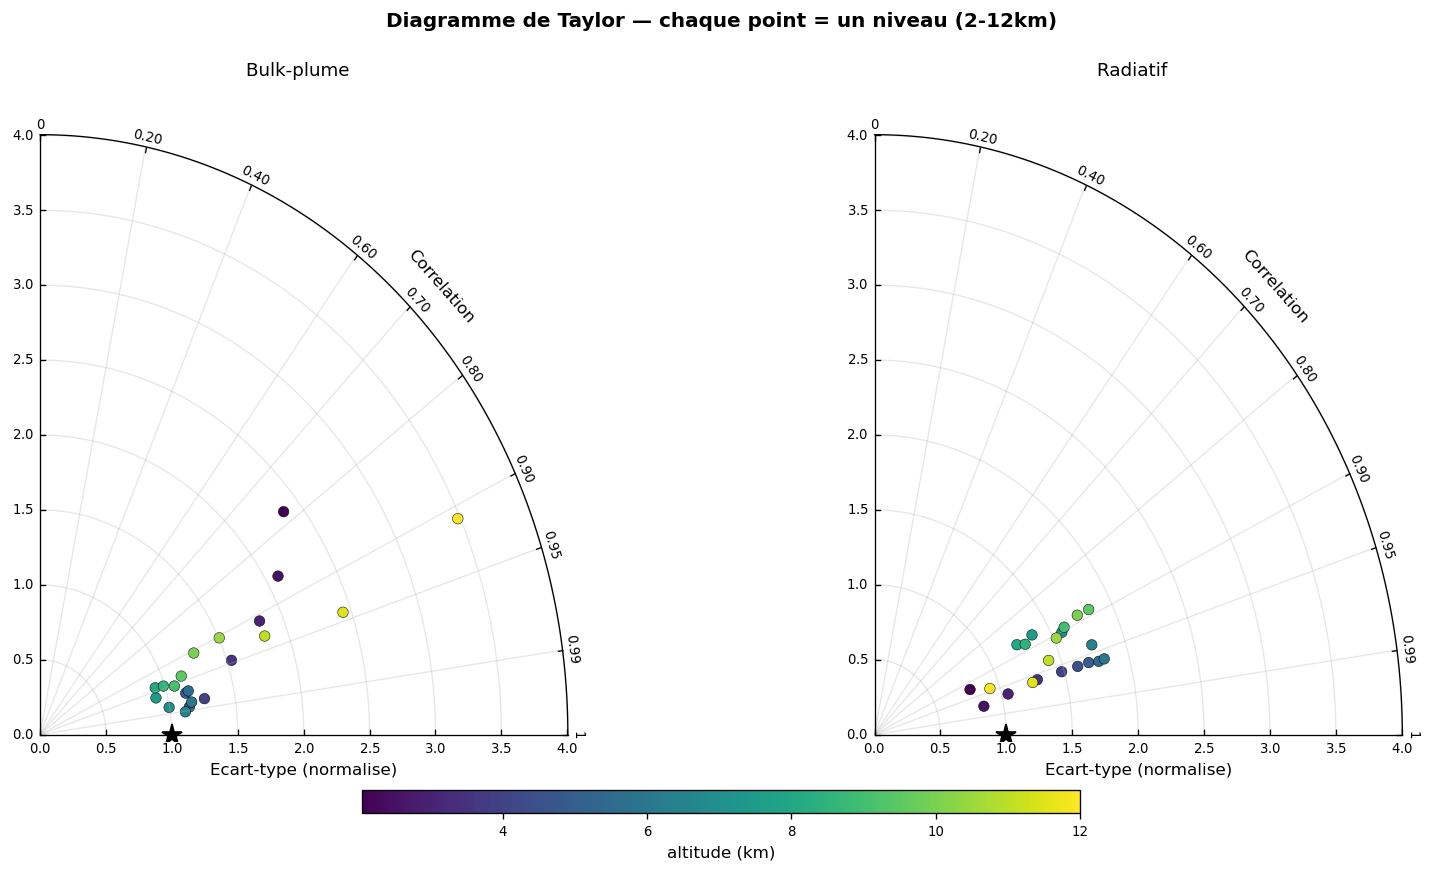

In [11]:
# ============================================================
#  Diagramme de Taylor : bulk-plume vs radiatif, cote a cote
#  (corr, ratio std, RMSE centre) — un point PAR NIVEAU dans la bande 2-12km
# ============================================================
from matplotlib.projections import PolarAxes
import mpl_toolkits.axisartist.floating_axes as FA
import mpl_toolkits.axisartist.grid_finder as GF

def taylor_axes(fig, subplot, std_max, title):
    tr = PolarAxes.PolarTransform()
    r_locs = np.array([0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0])
    t_locs = np.arccos(r_locs)
    gl1 = GF.FixedLocator(t_locs)
    tf1 = GF.DictFormatter(dict(zip(t_locs, [f"{v:.2f}" if v not in (0,1) else f"{v:.0f}" for v in r_locs])))
    ghelper = FA.GridHelperCurveLinear(tr, extremes=(0, np.pi/2, 0, std_max*1.15),
                                        grid_locator1=gl1, tick_formatter1=tf1)
    ax = FA.FloatingSubplot(fig, subplot, grid_helper=ghelper)
    fig.add_subplot(ax)

    ax.axis["top"].set_axis_direction("bottom")
    ax.axis["top"].toggle(ticklabels=True, label=True)
    ax.axis["top"].major_ticklabels.set_axis_direction("top")
    ax.axis["top"].major_ticklabels.set_fontsize(8)
    ax.axis["top"].label.set_axis_direction("top")
    ax.axis["top"].label.set_text("Correlation")
    ax.axis["top"].label.set_fontsize(10)
    ax.axis["top"].label.set_pad(8)

    ax.axis["left"].set_axis_direction("bottom")
    ax.axis["left"].label.set_text("Ecart-type (normalise)")
    ax.axis["left"].label.set_fontsize(10)
    ax.axis["left"].major_ticklabels.set_fontsize(8)

    ax.axis["right"].set_axis_direction("top")
    ax.axis["right"].toggle(ticklabels=True)
    ax.axis["right"].major_ticklabels.set_axis_direction("left")
    ax.axis["right"].major_ticklabels.set_fontsize(8)

    ax.axis["bottom"].set_visible(False)
    ax.grid(True, alpha=.3)

    ax_polar = ax.get_aux_axes(tr)
    ax_polar.plot([0], [1], 'k*', ms=13, zorder=10)
    ax.set_title(title, fontsize=11, pad=32)
    return ax, ax_polar

fig = plt.figure(figsize=(13, 7.5))
fig.subplots_adjust(left=0.06, right=0.94, top=0.82, bottom=0.14, wspace=0.55)

# --- calcul corr et ratio std, par niveau, dans m212, pour chaque prediction ---
def points_taylor(pred, mask):
    corrs, ratios, zs = [], [], []
    for iz in range(n_z):
        if not mask[iz]: continue
        a, b = dudt_reel[iz,:], pred[iz,:]
        ok = np.isfinite(a) & np.isfinite(b)
        if ok.sum() < 20 or np.std(a[ok]) < 1e-15 or np.std(b[ok]) < 1e-15: continue
        r = np.corrcoef(a[ok], b[ok])[0,1]
        ratio = np.std(b[ok]) / np.std(a[ok])
        corrs.append(r); ratios.append(ratio); zs.append(zkm[iz])
    return np.array(corrs), np.array(ratios), np.array(zs)

corr_b, ratio_b, z_b = points_taylor(dudt_pred_s, m212)
corr_r, ratio_r, z_r = points_taylor(dudt_pred_rad, m212)

std_max = max(ratio_b.max() if len(ratio_b) else 1, ratio_r.max() if len(ratio_r) else 1, 1.5)

ax1, axp1 = taylor_axes(fig, 121, std_max, 'Bulk-plume  ')
sc1 = axp1.scatter(np.arccos(corr_b), ratio_b, c=z_b, cmap='viridis', s=40, edgecolor='k', lw=.3)

ax2, axp2 = taylor_axes(fig, 122, std_max, 'Radiatif  ')
sc2 = axp2.scatter(np.arccos(corr_r), ratio_r, c=z_r, cmap='viridis', s=40, edgecolor='k', lw=.3)

# ============================================================
# --- colorbar : axes explicites places en bas, plus de superposition ---
# ============================================================
cax = fig.add_axes([0.27, 0.06, 0.46, 0.025])  # [left, bottom, width, height] en coords figure
cbar = fig.colorbar(sc2, cax=cax, orientation='horizontal')
cbar.set_label('altitude (km)', fontsize=10)
cbar.ax.tick_params(labelsize=8)

fig.suptitle("Diagramme de Taylor — chaque point = un niveau (2-12km)", fontweight='bold', fontsize=12, y=0.95)
plt.show()

ecart max entre calcul direct et decomposition (doit etre ~0) : 5.610e-07


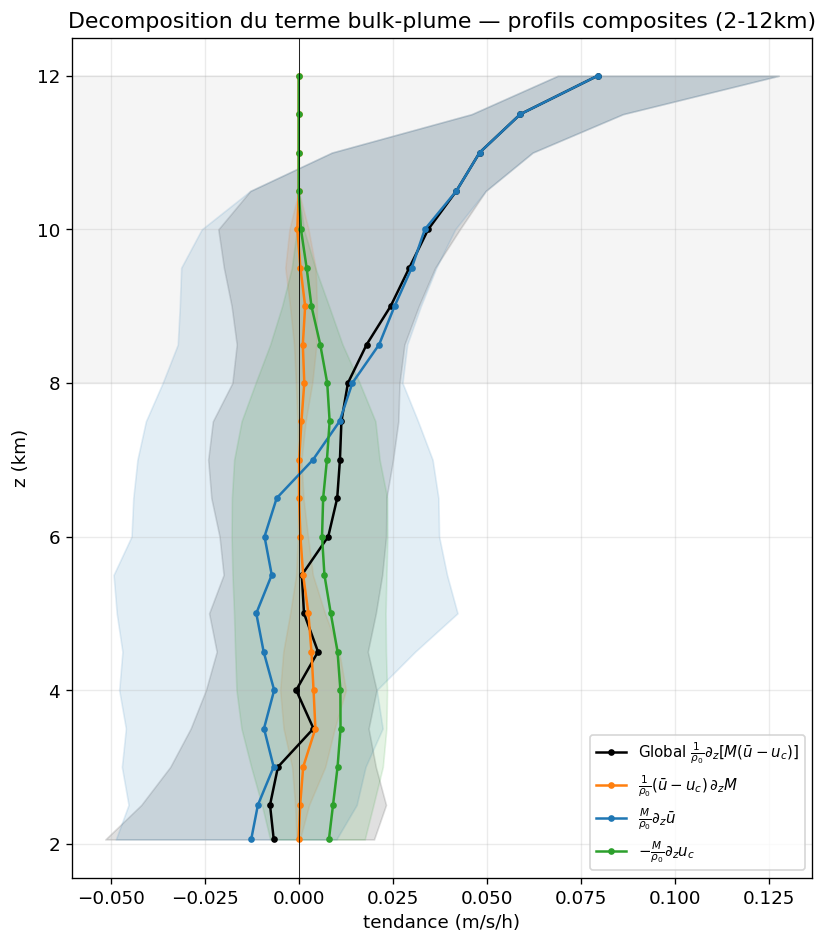

/tmp/ipykernel_36689/1176152910.py:69: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(tt+t_stat, zkm[m212], champ[m212]*3600, cmap='RdBu_r',


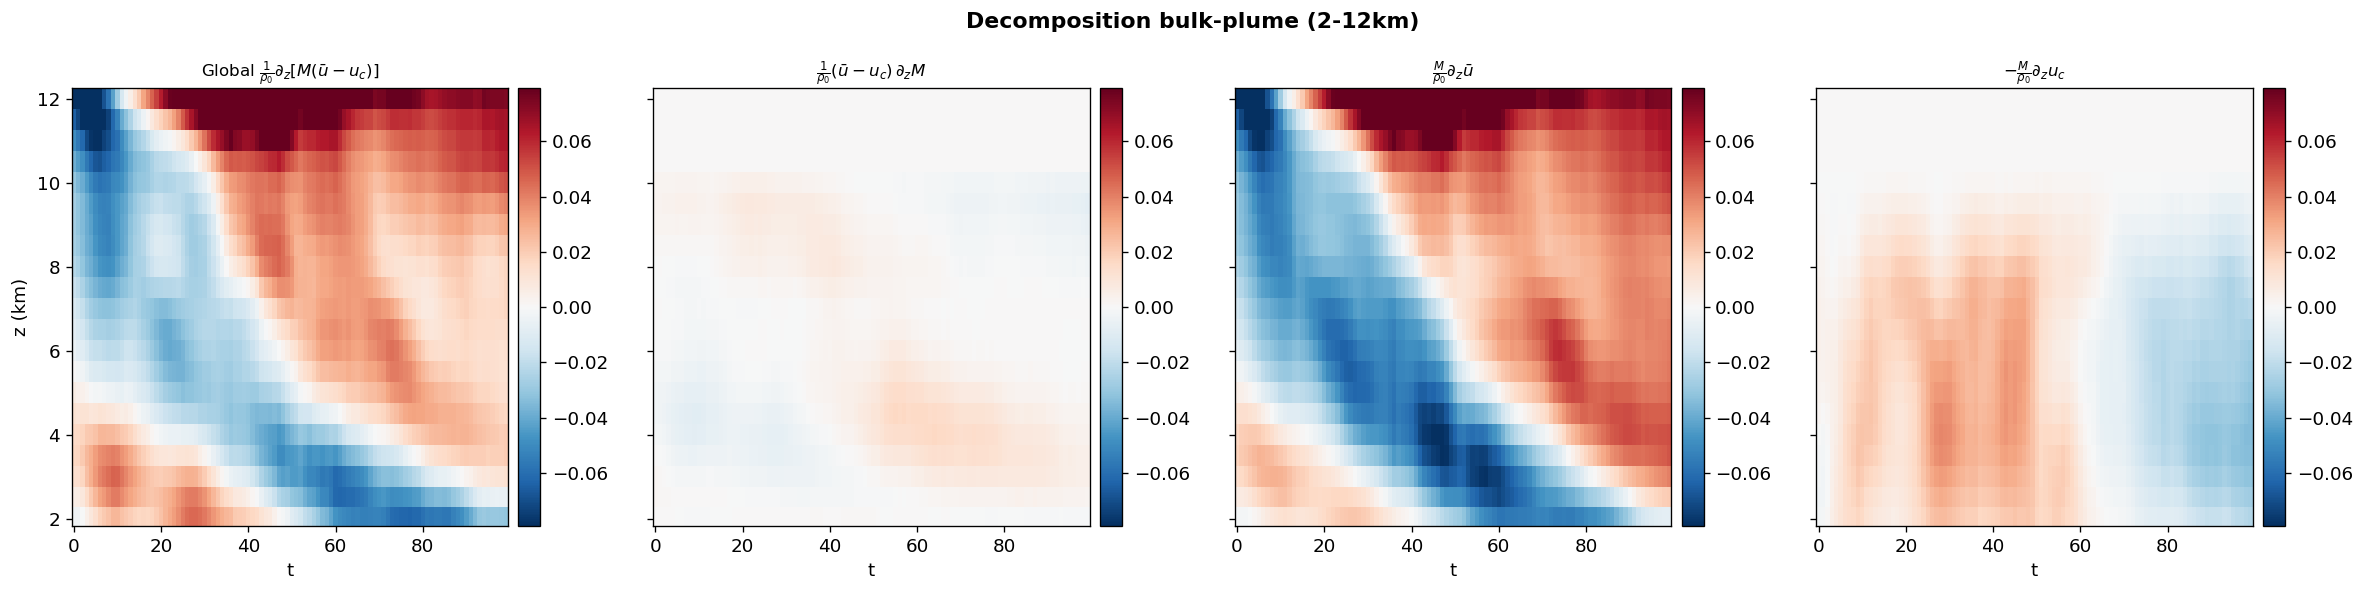

In [12]:
# ============================================================
#  Decomposition du produit dans (1/rho0)*d/dz[M(ubar-uc)]
#  = (1/rho0)*(ubar-uc)*dM/dz  +  (M/rho0)*d(ubar)/dz  -  (M/rho0)*d(uc)/dz
#  Affichage des 3 termes separes + le terme global, en profils composites
#  A executer tel quel dans chaque notebook (Meso-NH, UCLA, SCALE...)
# ============================================================

# --- derivees verticales necessaires ---
dM_dz_zt   = np.gradient(M_zt_lisse, alt, axis=0)
dubar_dz_zt = np.gradient(ubar_zt, alt, axis=0)
duc_dz_zt  = np.gradient(uc_zt_lisse, alt, axis=0)   # deja calcule plus haut dans tes notebooks (duc_dz_zt), garde si deja present

# --- les 3 termes de la decomposition, chacun (n_z, n_stat) ---
terme_dMdz = (1/rho0[:, None]) * (ubar_zt - uc_zt_lisse) * dM_dz_zt   # (1/rho0)*(ubar-uc)*dM/dz
terme_dubar = (M_zt_lisse/rho0[:, None]) * dubar_dz_zt                # (M/rho0)*d(ubar)/dz
terme_duc   = (M_zt_lisse/rho0[:, None]) * duc_dz_zt                  # (M/rho0)*d(uc)/dz

# --- terme global (deja calcule normalement = dudt_pred, avant lissage temporel) ---
dudt_pred_check = terme_dMdz + terme_dubar - terme_duc   # doit etre ~= dudt_pred calcule via np.gradient direct

# sanity check : les deux methodes de calcul du terme global doivent coincider
ecart_max = np.nanmax(np.abs(dudt_pred_check[m212] - dudt_pred[m212]))
print(f"ecart max entre calcul direct et decomposition (doit etre ~0) : {ecart_max:.3e}")

# --- lissage temporel de chaque terme, comme pour dudt_pred_s ---
terme_dMdz_s  = smooth_t(terme_dMdz)
terme_dubar_s = smooth_t(terme_dubar)
terme_duc_s   = smooth_t(terme_duc)

# ============================================================
#  Profils composites (median + IQR) des 4 quantites, cote a cote
# ============================================================
def profil_composite(champ_zt, mask):
    med = np.nanmedian(champ_zt[mask], axis=1)
    q25 = np.nanpercentile(champ_zt[mask], 25, axis=1)
    q75 = np.nanpercentile(champ_zt[mask], 75, axis=1)
    return med, q25, q75

termes = {
    r'Global $\frac{1}{\rho_0}\partial_z[M(\bar u-u_c)]$'      : dudt_pred_s,
    r'$\frac{1}{\rho_0}(\bar u-u_c)\,\partial_z M$'              : terme_dMdz_s,
    r'$\frac{M}{\rho_0}\partial_z\bar u$'                        : terme_dubar_s,
    r'$-\frac{M}{\rho_0}\partial_z u_c$'                         : -terme_duc_s,
}

fig, ax = plt.subplots(figsize=(7, 8))
for (label, champ), color in zip(termes.items(), ['k', 'tab:orange', 'tab:blue', 'tab:green']):
    med, q25, q75 = profil_composite(champ*3600, m212)   # m/s/h
    ax.plot(med, zkm[m212], 'o-', ms=3, color=color, label=label)
    ax.fill_betweenx(zkm[m212], q25, q75, color=color, alpha=.12)
ax.axvline(0, color='k', lw=.5)
ax.axhspan(8, 12, color='grey', alpha=.08)
ax.set_xlabel('tendance (m/s/h)')
ax.set_ylabel('z (km)')
ax.legend(fontsize=9, loc='best')
ax.set_title('Decomposition du terme bulk-plume — profils composites (2-12km)')
plt.tight_layout()
plt.show()

# ============================================================
#  Version pcolormesh (z,t) pour les 4 termes, comme tes autres figures
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
v = max(np.nanpercentile(np.abs(dudt_pred_s[m212]), 95),
        np.nanpercentile(np.abs(terme_dMdz_s[m212]), 95),
        np.nanpercentile(np.abs(terme_dubar_s[m212]), 95),
        np.nanpercentile(np.abs(terme_duc_s[m212]), 95)) * 3600 + 1e-12
for ax, (label, champ) in zip(axes, termes.items()):
    im = ax.pcolormesh(tt+t_stat, zkm[m212], champ[m212]*3600, cmap='RdBu_r',
                        norm=TwoSlopeNorm(0, -v, v), shading='auto')
    ax.set_xlabel('t'); ax.set_title(label, fontsize=10)
    fig.colorbar(im, ax=ax, pad=.02)
axes[0].set_ylabel('z (km)')
plt.suptitle("Decomposition bulk-plume (2-12km)", fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_36689/2965526625.py:22: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(tt+t_stat, zkm[m212], fld[m212], cmap='RdBu_r',


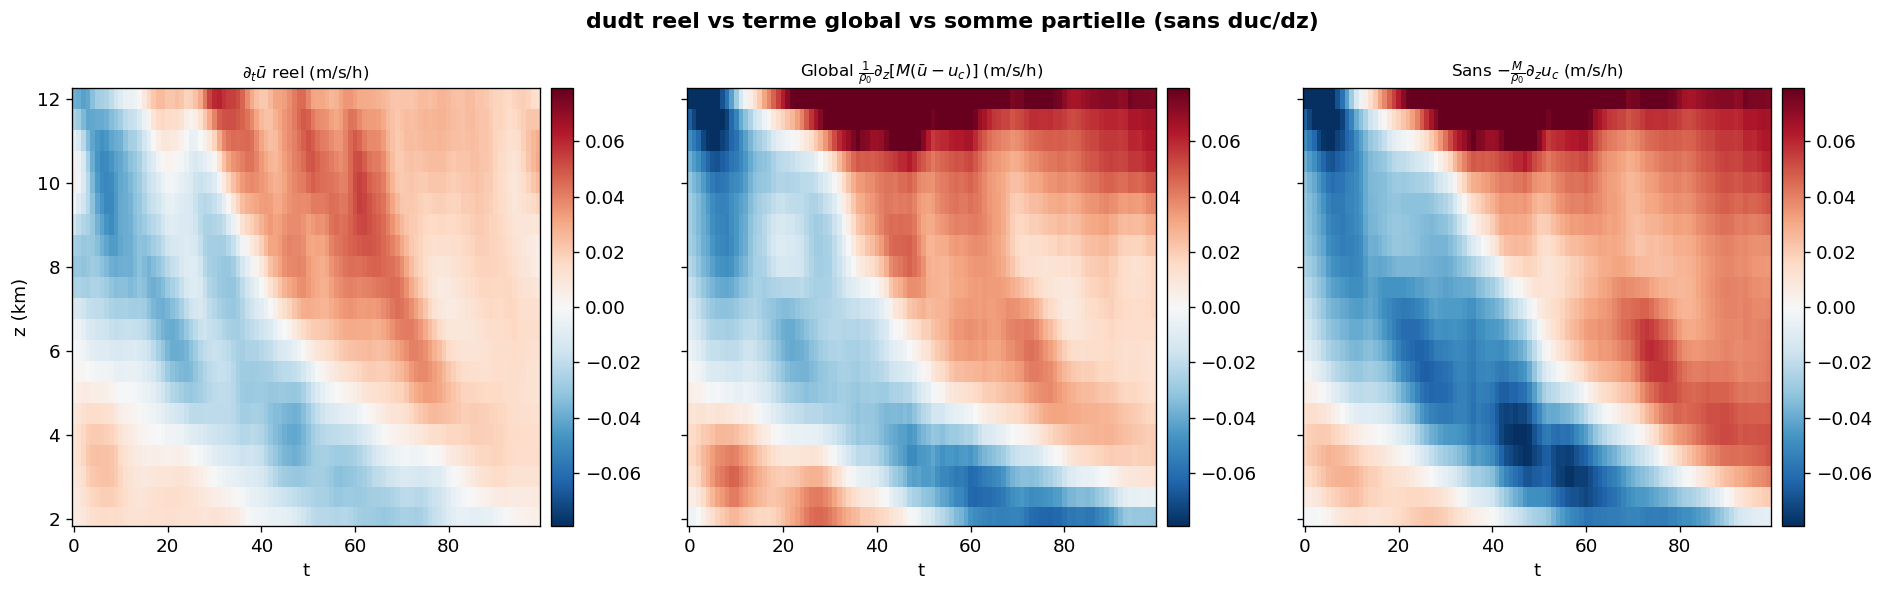

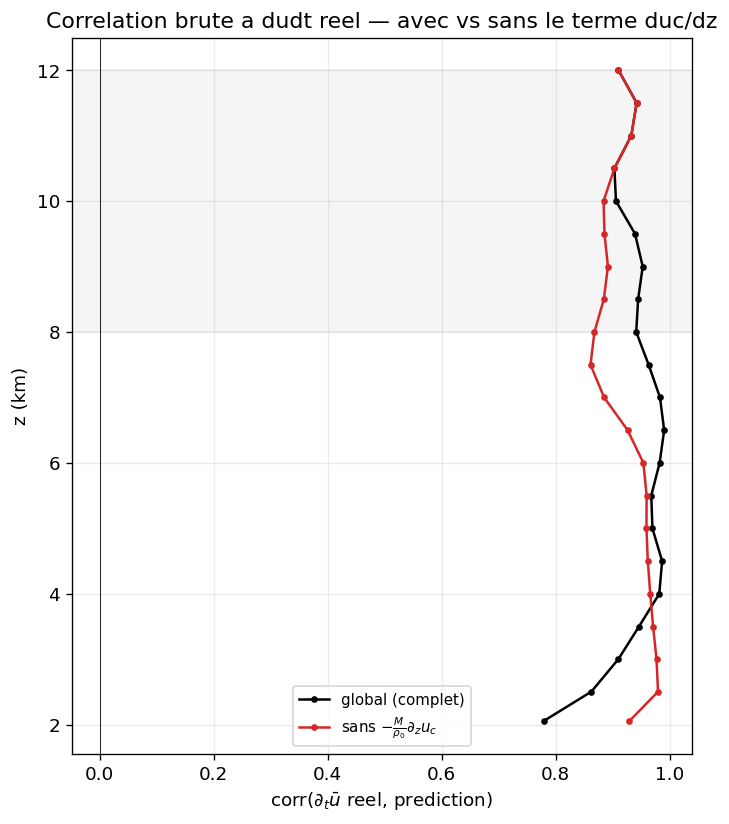

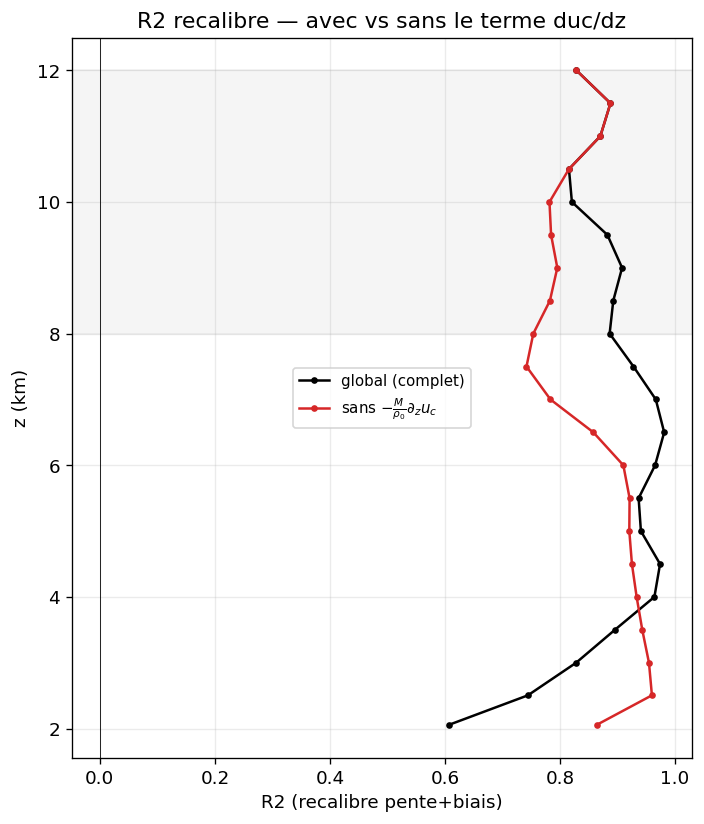

R2 median 2-8km  | global: 0.94 | sans duc/dz: 0.92
R2 median 8-12km | global: 0.88 | sans duc/dz: 0.80


In [13]:
# ============================================================
#  Comparaison a dudt_reel : uniquement la somme de
#     (1/rho0)*(ubar-uc)*dM/dz   +   (M/rho0)*d(ubar)/dz
#  c'est-a-dire le terme global SANS le morceau -(M/rho0)*d(uc)/dz
#  (test : est-ce que ce terme uc est vraiment necessaire ?)
#  A executer apres le bloc de decomposition precedent (termes deja calcules)
# ============================================================

somme_partielle_s =  terme_dubar_s   # = dudt_pred_s + terme_duc_s

# ============================================================
#  1) Cartes (z,t) : reel | terme global complet | somme partielle (sans duc)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
v = max(np.nanpercentile(np.abs(dudt_reel[m212]), 95),
        np.nanpercentile(np.abs(dudt_pred_s[m212]), 95),
        np.nanpercentile(np.abs(somme_partielle_s[m212]), 95)) * 3600 + 1e-12
for ax, (fld, lab) in zip(axes, [
        (dudt_reel*3600, r"$\partial_t\bar u$ reel (m/s/h)"),
        (dudt_pred_s*3600, r"Global $\frac{1}{\rho_0}\partial_z[M(\bar u-u_c)]$ (m/s/h)"),
        (somme_partielle_s*3600, r"Sans $-\frac{M}{\rho_0}\partial_z u_c$ (m/s/h)")]):
    im = ax.pcolormesh(tt+t_stat, zkm[m212], fld[m212], cmap='RdBu_r',
                        norm=TwoSlopeNorm(0, -v, v), shading='auto')
    ax.set_xlabel('t'); ax.set_title(lab, fontsize=10)
    fig.colorbar(im, ax=ax, pad=.02)
axes[0].set_ylabel('z (km)')
plt.suptitle("dudt reel vs terme global vs somme partielle (sans duc/dz)", fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
#  2) Correlation brute a dudt_reel, niveau par niveau, pour les deux versions
# ============================================================
def correlation_par_niveau(pred, mask):
    r = np.full(n_z, np.nan)
    for iz in range(n_z):
        if not mask[iz]: continue
        a, b = dudt_reel[iz, :], pred[iz, :]
        ok = np.isfinite(a) & np.isfinite(b)
        if ok.sum() < 20 or np.std(a[ok]) < 1e-15 or np.std(b[ok]) < 1e-15: continue
        r[iz] = np.corrcoef(a[ok], b[ok])[0, 1]
    return r

corr_global = correlation_par_niveau(dudt_pred_s, m212)
corr_partiel = correlation_par_niveau(somme_partielle_s, m212)

fig, ax = plt.subplots(figsize=(6, 7))
ax.plot(corr_global[m212], zkm[m212], 'o-', ms=3, color='k', label='global (complet)')
ax.plot(corr_partiel[m212], zkm[m212], 'o-', ms=3, color='tab:red', label=r'sans $-\frac{M}{\rho_0}\partial_z u_c$')
ax.axvline(0, color='k', lw=.5)
ax.axhspan(8, 12, color='grey', alpha=.08)
ax.set_xlabel(r'corr($\partial_t\bar u$ reel, prediction)')
ax.set_ylabel('z (km)')
ax.legend(fontsize=9)
ax.set_title('Correlation brute a dudt reel — avec vs sans le terme duc/dz')
plt.tight_layout()
plt.show()

# ============================================================
#  3) R2 recalibre (pente+biais), pour comparer proprement l'apport du terme duc/dz
# ============================================================
def r2_recalibre(pred, mask):
    pente = np.full(n_z, np.nan); biais = np.full(n_z, np.nan)
    for iz in range(n_z):
        if not mask[iz]: continue
        a, b = dudt_reel[iz, :], pred[iz, :]
        ok = np.isfinite(a) & np.isfinite(b)
        if ok.sum() < 20 or np.std(b[ok]) < 1e-15: continue
        A = np.vstack([b[ok], np.ones(ok.sum())]).T
        coefs, *_ = np.linalg.lstsq(A, a[ok], rcond=None)
        pente[iz], biais[iz] = coefs
    pred_cal = pente[:, None]*pred + biais[:, None]
    r2 = np.full(n_z, np.nan)
    for iz in range(n_z):
        if not mask[iz]: continue
        a, b = dudt_reel[iz, :], pred_cal[iz, :]
        ok = np.isfinite(a) & np.isfinite(b)
        if ok.sum() < 20 or np.std(a[ok]) < 1e-15: continue
        ss_res = np.sum((a[ok]-b[ok])**2); ss_tot = np.sum((a[ok]-a[ok].mean())**2)
        r2[iz] = 1-ss_res/ss_tot if ss_tot > 0 else np.nan
    return r2

R2_global = r2_recalibre(dudt_pred_s, m212)
R2_partiel = r2_recalibre(somme_partielle_s, m212)

fig, ax = plt.subplots(figsize=(6, 7))
ax.plot(R2_global[m212], zkm[m212], 'o-', ms=3, color='k', label='global (complet)')
ax.plot(R2_partiel[m212], zkm[m212], 'o-', ms=3, color='tab:red', label=r'sans $-\frac{M}{\rho_0}\partial_z u_c$')
ax.axvline(0, color='k', lw=.5)
ax.axhspan(8, 12, color='grey', alpha=.08)
ax.set_xlabel('R2 (recalibre pente+biais)')
ax.set_ylabel('z (km)')
ax.legend(fontsize=9)
ax.set_title('R2 recalibre — avec vs sans le terme duc/dz')
plt.tight_layout()
plt.show()

print(f"R2 median 2-8km  | global: {np.nanmedian(R2_global[m28]):.2f} | sans duc/dz: {np.nanmedian(R2_partiel[m28]):.2f}")
print(f"R2 median 8-12km | global: {np.nanmedian(R2_global[m812]):.2f} | sans duc/dz: {np.nanmedian(R2_partiel[m812]):.2f}")

  iz=0/73
  iz=10/73
  iz=20/73
  iz=30/73
  iz=40/73
  iz=50/73
  iz=60/73
  iz=70/73
controle |rey-(T1+T2)| max (z,t) = 1.24e-08 (doit etre ~0, identite exacte)


/tmp/ipykernel_36689/296645204.py:65: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(tt + t_stat, zkm[m212], fld[m212] * 1e3, cmap='RdBu_r',


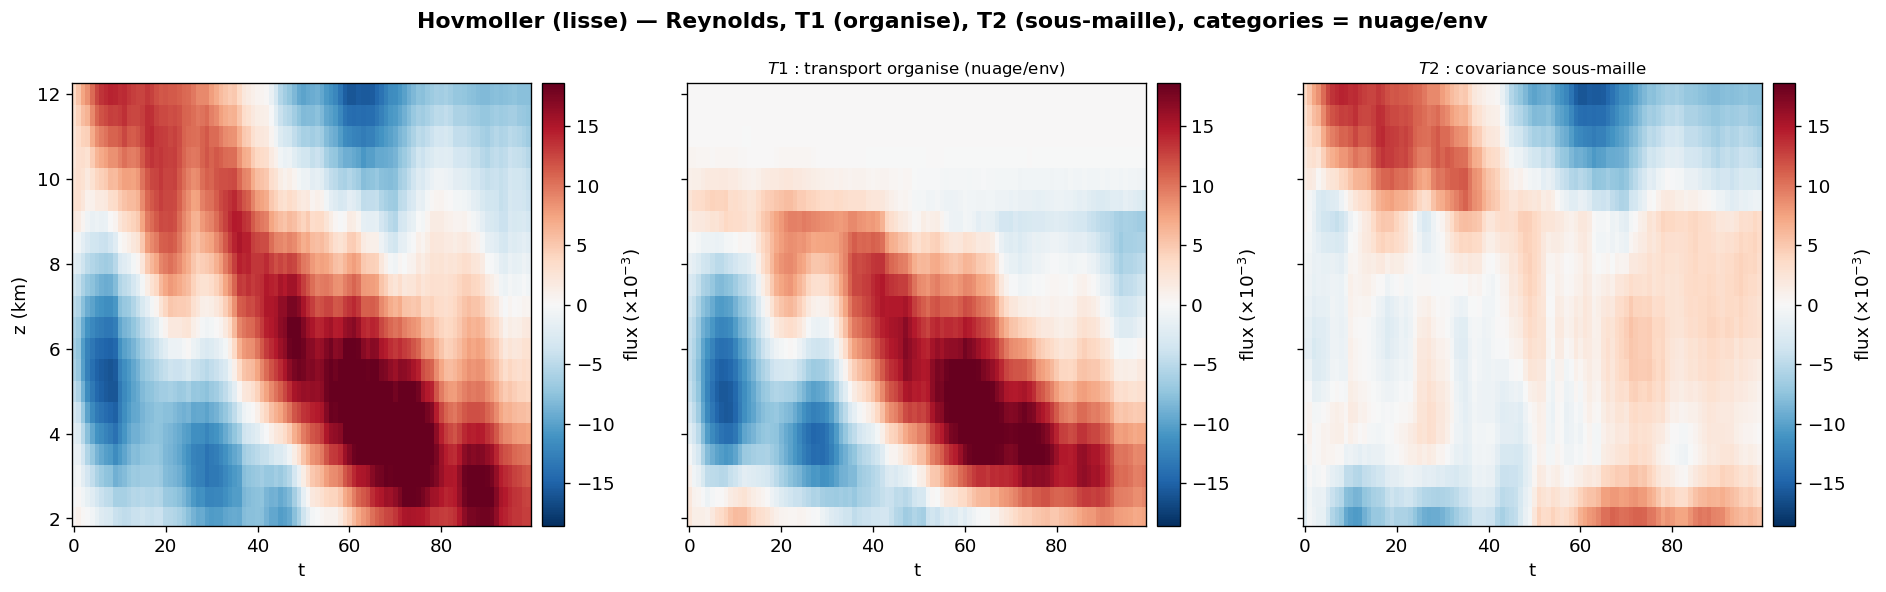

/tmp/ipykernel_36689/296645204.py:98: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(tt + t_stat, zkm[m212], fld[m212] * 3600, cmap='RdBu_r',


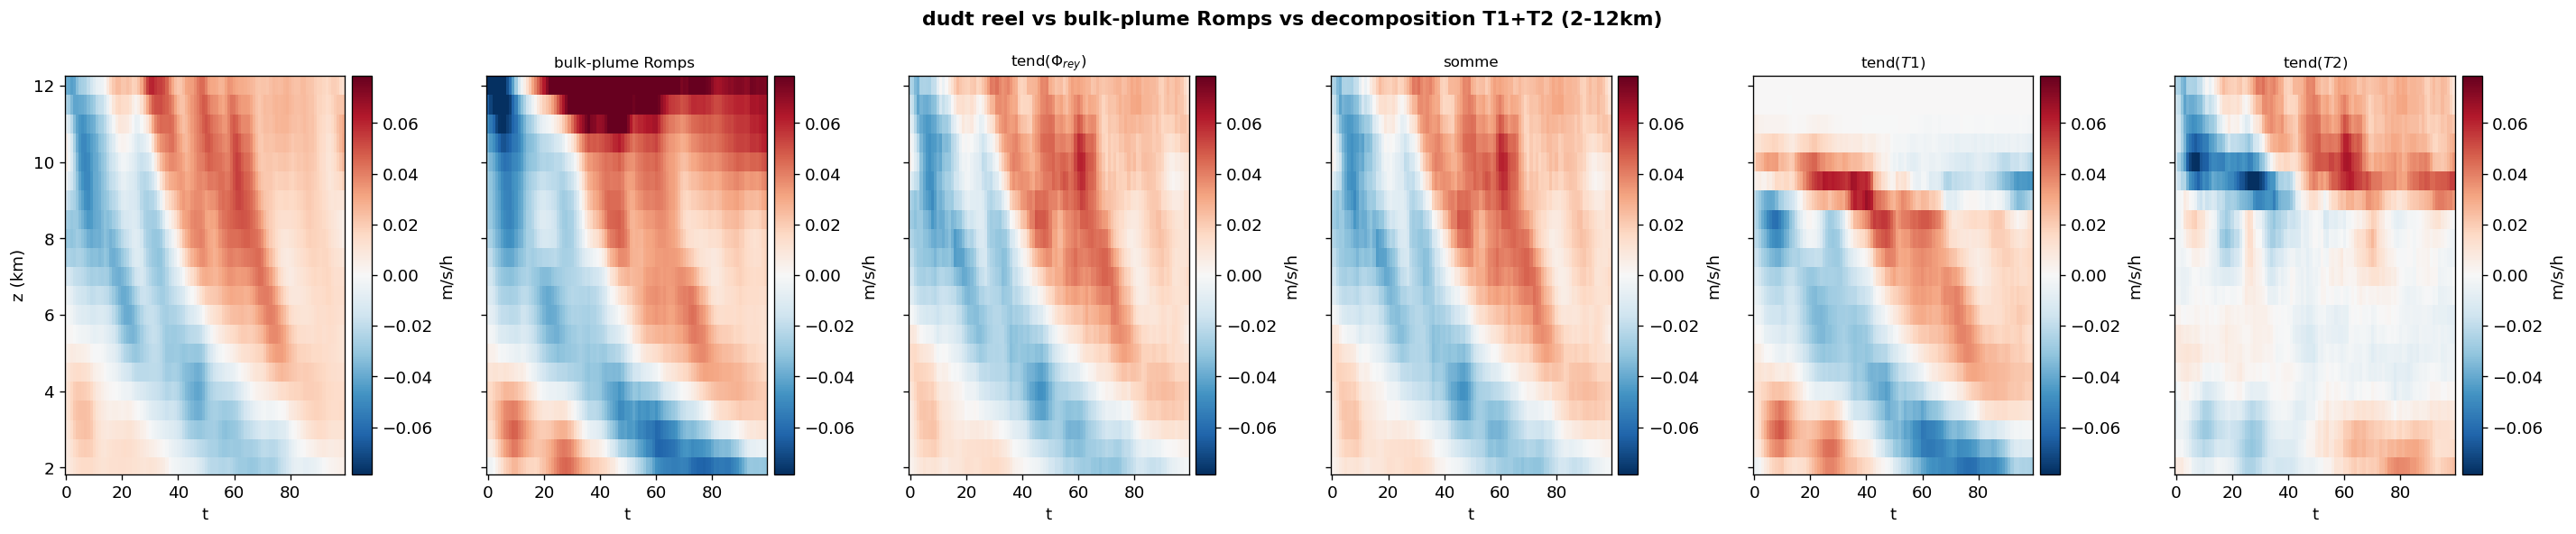

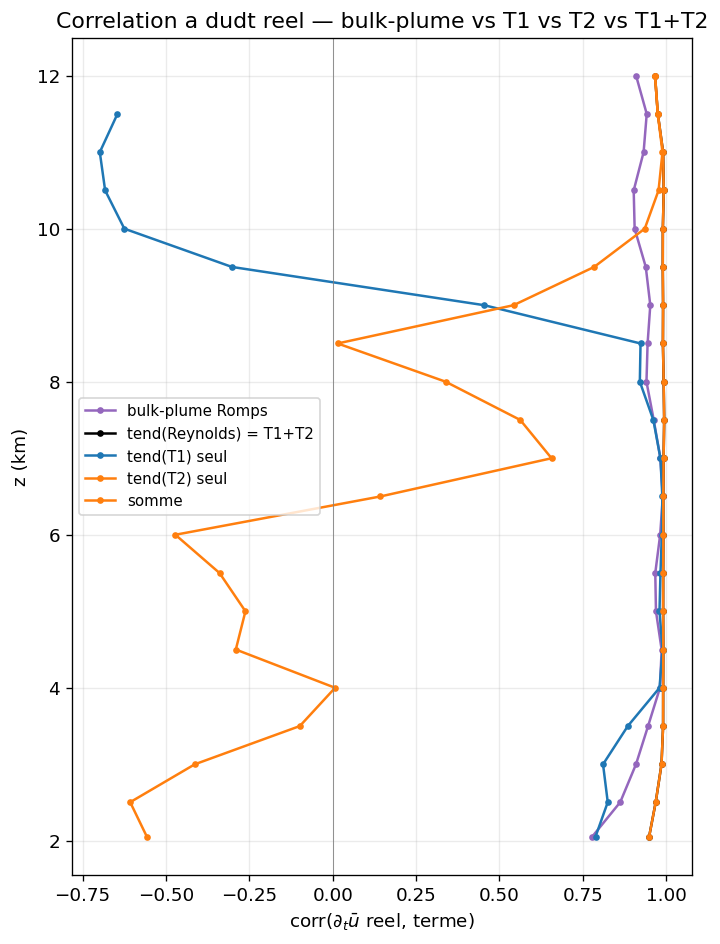

In [ ]:
# ============================================================
#  T1 (transport organise, moyennes conditionnelles) + T2 (covariance
#  sous-maille interne) — MEME MATHEMATIQUE que la cellule 23 du fichier 3 :
#     Phi_rey = SUM_cat sigma_cat*(u_cat-ubar)(w_cat-wbar)      [T1]
#             + SUM_cat sigma_cat*<(u-u_cat)(w-w_cat)>_cat       [T2]
#  Seule la definition des categories change : on reprend le masque
#  nuage exact du fichier 12 (SEUIL_W, SEUIL_COND) au lieu du seuil sur w,
#  pour rester coherent avec M et u_c deja calcules (cellule 19).
#  dudt_reel n'est pas touche (cellule 19).
# ============================================================
SEUIL_W = 0.5; SEUIL_COND = 1e-5

rey_zt = np.full((n_z, n_stat), np.nan)
T1_zt  = np.full((n_z, n_stat), np.nan)
T2_zt  = np.full((n_z, n_stat), np.nan)

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
ds_clw = xr.open_dataset(path3d('clw')) 
for iz in range(n_z):
    u = ds_u['ua'].isel({dim_t: idx_stat, dim_z: iz}).values.reshape(n_stat, -1)
    w = ds_w['wa'].isel({dim_t: idx_stat, dim_z: iz}).values.reshape(n_stat, -1)
    clw = ds_clw['clw'].isel({dim_t: idx_stat, dim_z: iz}).values.reshape(n_stat, -1)
    cloud = (w > SEUIL_W) & ((clw) > SEUIL_COND)

    for it in range(n_stat):
        uu, ww = u[it, :], w[it, :]
        ub, wb = uu.mean(), ww.mean()
        N = uu.size

        rey_zt[iz, it] = rho0[iz] * ((uu - ub) * (ww - wb)).mean()

        cats = {'cloud': cloud[it, :], 'env': ~cloud[it, :]}
        t1_acc = 0.0; t2_acc = 0.0
        for name, msk in cats.items():
            if not msk.any(): continue
            sig = msk.sum() / N
            uc, wc = uu[msk].mean(), ww[msk].mean()
            t1_acc += sig * (uc - ub) * (wc - wb)
            t2_acc += sig * ((uu[msk] - uc) * (ww[msk] - wc)).mean()
        T1_zt[iz, it] = rho0[iz] * t1_acc
        T2_zt[iz, it] = rho0[iz] * t2_acc

    del u, w, clw, cloud
    if iz % 10 == 0: print(f'  iz={iz}/{n_z-1}')
    gc.collect()
ds_u.close(); ds_w.close(); ds_clw.close(); gc.collect()

resid = rey_zt - (T1_zt + T2_zt)
print(f'controle |rey-(T1+T2)| max (z,t) = {np.nanmax(np.abs(resid)):.2e} (doit etre ~0, identite exacte)')

# --- lissage temporel, meme convention que le reste du fichier ---
rey_zt_s = smooth_t(rey_zt)
T1_zt_s  = smooth_t(T1_zt)
T2_zt_s  = smooth_t(T2_zt)

# ============================================================
#  ETAPE 1 — Hovmoller : Reynolds, T1 (organise), T2 (covariance sous-maille)
# ============================================================
v1 = np.nanpercentile(np.abs(rey_zt_s[m212]), 95) * 1e3 + 1e-12
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, (fld, lab) in zip(axes, [
        (rey_zt_s, r''),
        (T1_zt_s,  r'$T1$ : transport organise (nuage/env)'),
        (T2_zt_s,  r'$T2$ : covariance sous-maille')]):
    im = ax.pcolormesh(tt + t_stat, zkm[m212], fld[m212] * 1e3, cmap='RdBu_r',
                        norm=TwoSlopeNorm(0, -v1, v1), shading='auto')
    ax.set_xlabel('t'); ax.set_title(lab, fontsize=10)
    fig.colorbar(im, ax=ax, pad=.02, label=r'flux ($\times10^{-3}$)')
axes[0].set_ylabel('z (km)')
plt.suptitle('Hovmoller (lisse) — Reynolds, T1 (organise), T2 (sous-maille), categories = nuage/env', fontweight='bold')
plt.tight_layout(); plt.show()

# ============================================================
#  ETAPE 2 — tendances -(1/rho0)*d/dz, comparees a dudt_reel (INCHANGE)
#  ET a dudt_pred_s (bulk-plume Romps, deja calcule cellule 19)
# ============================================================
def tend_zt(champ_zt):
    return -np.gradient(champ_zt, alt, axis=0) / rho0[:, None]

drey_zt = smooth_t(tend_zt(rey_zt))
dT1_zt  = smooth_t(tend_zt(T1_zt))
dT2_zt  = smooth_t(tend_zt(T2_zt))
somme = dT1_zt + dT2_zt


v2 = max(np.nanpercentile(np.abs(dudt_reel[m212]), 95),
         np.nanpercentile(np.abs(drey_zt[m212]), 95),
         np.nanpercentile(np.abs(dudt_pred_s[m212]), 95)) * 3600 + 1e-12

fig, axes = plt.subplots(1, 6, figsize=(24, 5), sharey=True)
for ax, (fld, lab) in zip(axes, [
        (dudt_reel,    r""),
        (dudt_pred_s,  r"bulk-plume Romps "),
        (drey_zt,      r"tend($\Phi_{rey}$)"),
        (somme,      r"somme"),
        (dT1_zt,       r"tend($T1$)"),
        (dT2_zt,       r"tend($T2$)")]):
    im = ax.pcolormesh(tt + t_stat, zkm[m212], fld[m212] * 3600, cmap='RdBu_r',
                        norm=TwoSlopeNorm(0, -v2, v2), shading='auto')
    ax.set_xlabel('t'); ax.set_title(lab, fontsize=10)
    fig.colorbar(im, ax=ax, pad=.02, label='m/s/h')
axes[0].set_ylabel('z (km)')
plt.suptitle('dudt reel vs bulk-plume Romps vs decomposition T1+T2 (2-12km)', fontweight='bold')
plt.tight_layout(); plt.show()

# ============================================================
#  Correlation brute a dudt_reel, niveau par niveau — 4 candidats
# ============================================================
def correlation_par_niveau(pred, mask):
    r = np.full(n_z, np.nan)
    for iz in range(n_z):
        if not mask[iz]: continue
        a, b = dudt_reel[iz, :], pred[iz, :]
        ok = np.isfinite(a) & np.isfinite(b)
        if ok.sum() < 20 or np.std(a[ok]) < 1e-15 or np.std(b[ok]) < 1e-15: continue
        r[iz] = np.corrcoef(a[ok], b[ok])[0, 1]
    return r

corr_bulk = correlation_par_niveau(dudt_pred_s, m212)
corr_rey  = correlation_par_niveau(drey_zt, m212)
corr_T1   = correlation_par_niveau(dT1_zt, m212)
corr_T2   = correlation_par_niveau(dT2_zt, m212)
corr_somme = correlation_par_niveau(somme, m212)

fig, ax = plt.subplots(figsize=(6, 8))
ax.plot(corr_bulk[m212], zkm[m212], 'o-', ms=3, color='tab:purple', label='bulk-plume Romps')
ax.plot(corr_rey[m212],  zkm[m212], 'o-', ms=3, color='k',          label='tend(Reynolds) = T1+T2')
ax.plot(corr_T1[m212],   zkm[m212], 'o-', ms=3, color='tab:blue',   label='tend(T1) seul')
ax.plot(corr_T2[m212],   zkm[m212], 'o-', ms=3, color='tab:orange', label='tend(T2) seul')
ax.plot(corr_somme[m212],   zkm[m212], 'o-', ms=3, color='tab:orange', label='somme')
ax.axvline(0, color='grey', lw=.5)
ax.set_xlabel(r'corr($\partial_t\bar u$ reel, terme)')
ax.set_ylabel('z (km)')
ax.legend(fontsize=9)
ax.set_title('Correlation a dudt reel — bulk-plume vs T1 vs T2 vs T1+T2')
plt.tight_layout(); plt.show()